# IMAGE SEGMENTATION WITH K-MEANS

## 0. Import thư viện & đọc ảnh

In [3]:
%matplotlib inline

import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.optimize import linear_sum_assignment

Kich thuoc anh: 1200x770, tong 924000 pixel


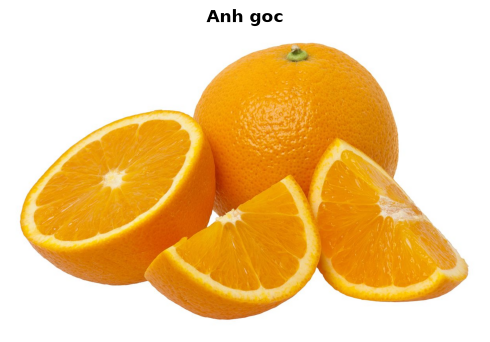

In [4]:
IMG_PATH = "../../data/images/orange.jpg" 

def load_image_rgb(path):
    bgr = cv2.imread(path)
    if bgr is None:
        raise FileNotFoundError(f"Không tìm thấy ảnh: {path}")
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

rgb_img = load_image_rgb(IMG_PATH)
h, w, c = rgb_img.shape
pixels = rgb_img.reshape((-1, 3)).astype(np.float64)
print(f"Kích thước ảnh: {w}x{h}, tổng {pixels.shape[0]} pixel")

plt.figure(figsize=(5, 4))
plt.imshow(rgb_img)
plt.title("Anh goc", fontweight="bold")
plt.axis("off")
plt.tight_layout()
plt.show()

## Phân đoạn với nhiều giá trị k

Chạy K-Means voi `k in {2, 3, 4, 5}` và hiển thị ảnh gốc và các ảnh phân đoạn tương ứng.

In [6]:
k_values = [2, 3, 4, 5]
segmented_images = {}
centers_by_k    = {}
labels_by_k     = {}

for k in k_values:
    km = KMeans(n_clusters=k, init="k-means++", n_init=5, max_iter=100, random_state=42)
    labels  = km.fit_predict(pixels)
    centers = np.round(km.cluster_centers_).astype(np.uint8) 
    segmented_images[k] = centers[labels].reshape(h, w, 3)
    centers_by_k[k]     = centers
    labels_by_k[k]      = labels
    print(f"k={k}: done")

k=2: done
k=3: done
k=4: done
k=5: done


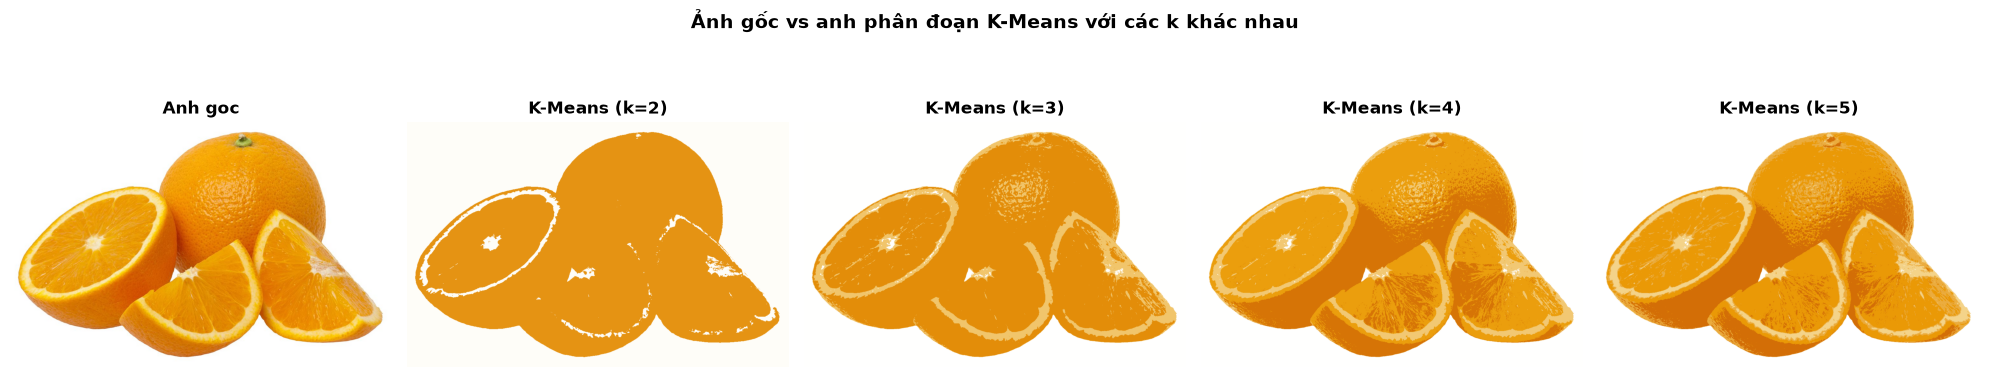

In [7]:
fig, axes = plt.subplots(1, len(k_values) + 1, figsize=(4 * (len(k_values) + 1), 4.5))

axes[0].imshow(rgb_img)
axes[0].set_title("Anh goc", fontweight="bold")
axes[0].axis("off")

for i, k in enumerate(k_values):
    axes[i + 1].imshow(segmented_images[k])
    axes[i + 1].set_title(f"K-Means (k={k})", fontweight="bold")
    axes[i + 1].axis("off")

plt.suptitle("Ảnh gốc vs anh phân đoạn K-Means với các k khác nhau",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Nhận xét:** Khi `k` tăng, ảnh phân đoạn giữ lại nhiều màu sắc hơn, gần với ảnh gốc hơn, nhưng mỗi vùng trở nên nhỏ hơn và chi tiết hơn.

## Implementation vs Thư viện sklearn

So sánh implementation K-Means (`fast_kmeans_image`) với `sklearn.KMeans`

In [8]:
def fast_kmeans_image(pixels, n_clusters=4, max_iter=100, tol=1e-4, random_state=42):
    rng = np.random.default_rng(random_state)
    n_samples = pixels.shape[0]

    # random sample
    idx = rng.choice(n_samples, n_clusters, replace=False)
    centroids = pixels[idx].astype(np.float64)

    for iteration in range(max_iter):
        # (N, k) khoang cach tu moi pixel toi moi tam cum
        dists  = np.linalg.norm(pixels[:, None, :] - centroids[None, :, :], axis=2)
        labels = np.argmin(dists, axis=1)

        new_centroids = np.array([
            pixels[labels == j].mean(axis=0) if np.any(labels == j) else centroids[j]
            for j in range(n_clusters)
        ])
        shift = np.linalg.norm(new_centroids - centroids)
        centroids = new_centroids
        if shift < tol:
            break

    return centroids, labels, iteration + 1


def match_labels(centroids_a, labels_a, centroids_b):
    cost = np.linalg.norm(centroids_a[:, None, :] - centroids_b[None, :, :], axis=2)
    row_ind, col_ind = linear_sum_assignment(cost)
    remap = dict(zip(row_ind, col_ind))
    return np.vectorize(remap.get)(labels_a)

print("Function definition done.")

Function definition done.


In [9]:
K_COMPARE = 4

print(f"Run K-Means (k={K_COMPARE})...")
custom_centroids, custom_labels_raw, n_iter = fast_kmeans_image(
    pixels, n_clusters=K_COMPARE, max_iter=100
)
sklearn_centroids = centers_by_k[K_COMPARE].astype(np.float64)
sklearn_labels    = labels_by_k[K_COMPARE]

custom_labels = match_labels(custom_centroids, custom_labels_raw, sklearn_centroids)
agreement = np.mean(custom_labels == sklearn_labels) * 100

print(f"Hoi tu sau {n_iter} vong lap.")
print(f"Ti le pixel co cung nhan cum (sau Hungarian matching): {agreement:.2f}%")

Run K-Means (k=4)...
Hoi tu sau 41 vong lap.
Ti le pixel co cung nhan cum (sau Hungarian matching): 99.30%


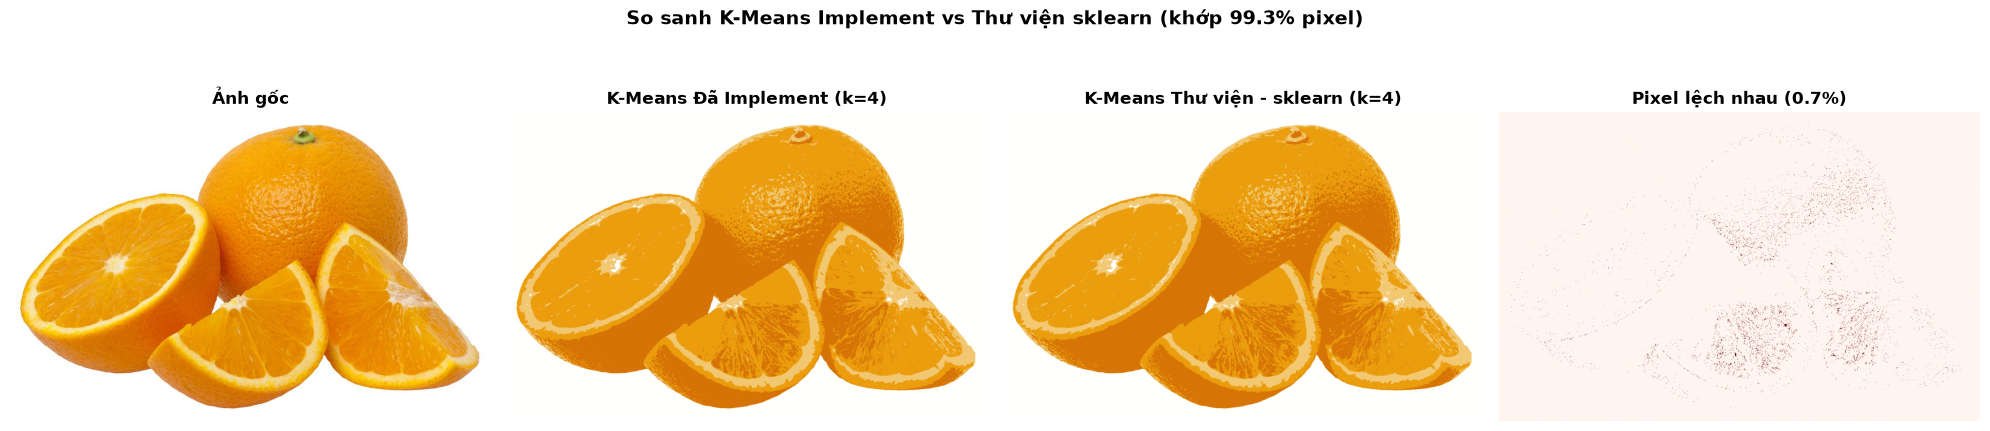

In [10]:
custom_centers_uint8 = np.round(custom_centroids).astype(np.uint8)
custom_segmented     = custom_centers_uint8[custom_labels_raw].reshape(h, w, 3)
sklearn_segmented    = segmented_images[K_COMPARE]
mismatch_map         = (custom_labels != sklearn_labels).reshape(h, w)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(rgb_img)
axes[0].set_title("Ảnh gốc", fontweight="bold")

axes[1].imshow(custom_segmented)
axes[1].set_title(f"K-Means Đã Implement (k={K_COMPARE})", fontweight="bold")

axes[2].imshow(sklearn_segmented)
axes[2].set_title(f"K-Means Thư viện - sklearn (k={K_COMPARE})", fontweight="bold")

axes[3].imshow(mismatch_map, cmap="Reds")
axes[3].set_title(f"Pixel lệch nhau ({100 - agreement:.1f}%)", fontweight="bold")

for ax in axes:
    ax.axis("off")

plt.suptitle(
    f"So sanh K-Means Implement vs Thư viện sklearn (khớp {agreement:.1f}% pixel)",
    fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.show()